# StayGuard: Predicting Hotel Booking Cancellations with Machine Learning

## 1. Project Overview

Hotel booking cancellations create uncertainty for hotels, affecting revenue forecasting, occupancy planning, staffing, and pricing decisions.

The goal of this project is to build a supervised machine learning model that predicts whether a hotel reservation is likely to be cancelled based on booking information available before arrival.

This first notebook focuses on data loading, initial exploration, cleaning, and preparation for modeling.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [27]:
from matplotlib.ticker import PercentFormatter

# Project color palette based on the StayGuard visual identity

project_palette = {
    "hotel_navy": "#173247",
    "hotel_blue": "#35566B",
    "slate_blue": "#5E7A8C",
    "soft_teal": "#8FB3BD",
    "pale_blue": "#DCE8EC",
    "ice_blue": "#EDF3F5",
    "off_white": "#F7F8F5",
    "charcoal": "#2F2F2F",
    "muted_gray": "#8C969C",
    "light_gray": "#D9DEE2",
    "grid_gray": "#E4E8EA",
    "muted_gold": "#C7A66A",
    "soft_gold": "#E6D3A3",
    "cancel_accent": "#C96A5B"
}

# Semantic chart colors

chart_colors = {
    "not_canceled": project_palette["pale_blue"],
    "canceled": project_palette["hotel_blue"],
    "main_model": project_palette["muted_gold"],
    "secondary_model": project_palette["slate_blue"],
    "baseline_model": project_palette["muted_gray"],
    "highlight": project_palette["muted_gold"],
    "neutral": project_palette["light_gray"],
    "text": project_palette["charcoal"],
    "grid": project_palette["grid_gray"]
}

# Target palette

booking_status_palette = {
    "Not_Canceled": chart_colors["not_canceled"],
    "Canceled": chart_colors["canceled"]
}

# Model comparison palette

model_palette = {
    "Logistic Regression Baseline": chart_colors["baseline_model"],
    "KNN Baseline": chart_colors["baseline_model"],
    "KNN Tuned": chart_colors["secondary_model"],
    "Decision Tree": chart_colors["secondary_model"],
    "Random Forest": chart_colors["secondary_model"],
    "Gradient Boosting Base": chart_colors["secondary_model"],
    "Gradient Boosting Tuned": chart_colors["main_model"]
}

In [28]:
sns.set_theme(style="whitegrid")

plt.rcParams["axes.edgecolor"] = project_palette["light_gray"]
plt.rcParams["axes.labelcolor"] = chart_colors["text"]
plt.rcParams["xtick.color"] = chart_colors["text"]
plt.rcParams["ytick.color"] = chart_colors["text"]
plt.rcParams["text.color"] = chart_colors["text"]
plt.rcParams["grid.color"] = chart_colors["grid"]
plt.rcParams["grid.alpha"] = 0.45

## 2. Data Loading

The dataset contains hotel reservation records, including guest information, length of stay, room type, lead time, market segment, previous booking behavior, room price, special requests, and booking status.

The target variable for this classification problem is `booking_status`.

In [29]:
df = pd.read_csv("../data/raw/Hotel Reservations.csv")

df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## 3. Initial Data Inspection

Before cleaning or modeling, we inspect the dataset structure, column names, missing values, duplicates, data types, and target distribution.

In [30]:
# Standardize column names

df.columns = df.columns.str.strip().str.lower()

df.head()

,booking_id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [31]:
# Dataset overview

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated booking IDs: {df['booking_id'].duplicated().sum()}")
print(f"Missing values: {df.isna().sum().sum()}")

Rows: 36275
Columns: 19
Duplicated rows: 0
Duplicated booking IDs: 0
Missing values: 0


In [32]:
# Data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   booking_id                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [33]:
# Target distribution

target_summary = pd.DataFrame({
    "count": df["booking_status"].value_counts(),
    "percentage": df["booking_status"].value_counts(normalize=True).mul(100).round(2)
})

target_summary

,count,percentage
booking_status,,
Not_Canceled,24390,67.24
Canceled,11885,32.76


### Initial Observations

The dataset contains 36,275 bookings and 19 columns. There are no missing values or duplicated booking IDs, which simplifies the initial cleaning process.

The next step is to inspect the target variable and the main categorical features before preparing the data for machine learning.

### Target Distribution

The target variable is moderately imbalanced: around two thirds of the bookings were not cancelled, while one third were cancelled.

This is important for model evaluation. Accuracy alone may be misleading because a simple baseline model predicting only the majority class would already achieve around 67% accuracy.

For this reason, later model evaluation will also consider metrics such as precision, recall, F1-score, and the confusion matrix.

## 4. Categorical Feature Inspection

Categorical variables need to be reviewed before modeling to detect inconsistent labels, rare categories, or variables that may require encoding.

In this section, we inspect the unique values and frequency distribution of the main categorical columns.

In [34]:
# Identify categorical columns

categorical_cols = df.select_dtypes(include="object").columns.tolist()

categorical_cols

['booking_id',
 'type_of_meal_plan',
 'room_type_reserved',
 'market_segment_type',
 'booking_status']

In [35]:
# Frequency distribution of categorical variables

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


booking_id
booking_id
INN00001    1
INN24187    1
INN24181    1
INN24182    1
INN24183    1
           ..
INN12086    1
INN12085    1
INN12084    1
INN12083    1
INN36275    1
Name: count, Length: 36275, dtype: int64

type_of_meal_plan
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64

room_type_reserved
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

market_segment_type
market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

booking_status
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [36]:
# Categorical predictor columns

categorical_features = [col for col in categorical_cols if col not in ["booking_id", "booking_status"]]

categorical_features

['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

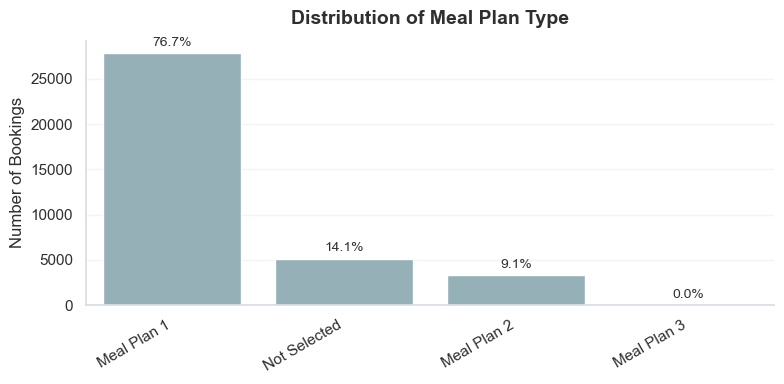

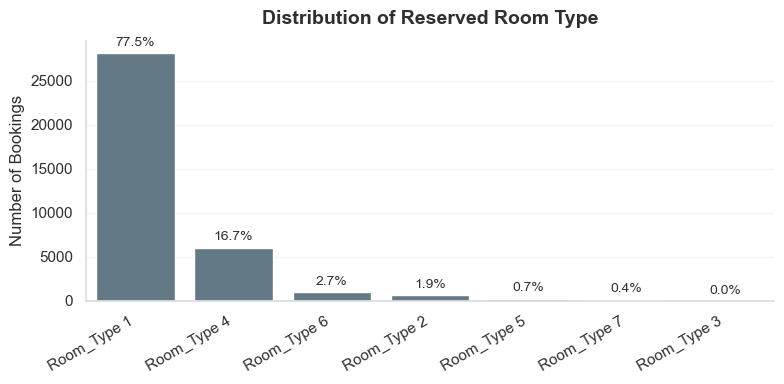

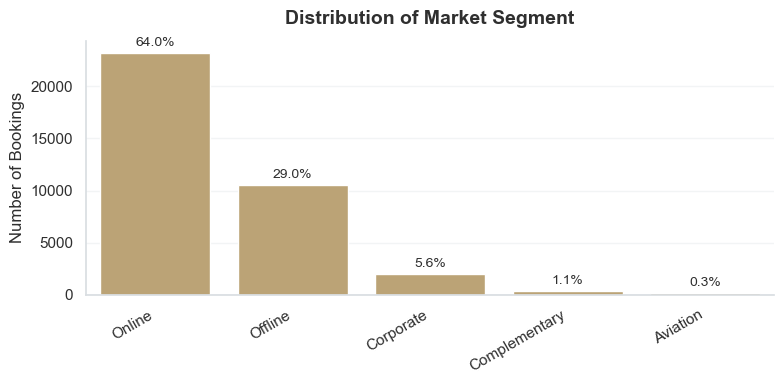

In [37]:
# Visualize categorical feature distributions with theme-based colors

categorical_feature_colors = {
    "type_of_meal_plan": project_palette["soft_teal"],
    "room_type_reserved": project_palette["slate_blue"],
    "market_segment_type": project_palette["muted_gold"]
}

categorical_feature_titles = {
    "type_of_meal_plan": "Distribution of Meal Plan Type",
    "room_type_reserved": "Distribution of Reserved Room Type",
    "market_segment_type": "Distribution of Market Segment"
}

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    
    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        color=categorical_feature_colors.get(col, project_palette["hotel_blue"])
    )
    
    total = len(df)
    
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v.get_height()/total:.1%}" for v in container],
            padding=3,
            color=chart_colors["text"],
            fontsize=10
        )
    
    plt.title(
        categorical_feature_titles.get(col, f"Distribution of {col}"),
        fontsize=14,
        weight="bold",
        pad=12,
        color=chart_colors["text"]
    )
    
    plt.xlabel("")
    plt.ylabel("Number of Bookings", color=chart_colors["text"])
    plt.xticks(rotation=30, ha="right", color=chart_colors["text"])
    plt.yticks(color=chart_colors["text"])
    plt.grid(axis="y", color=chart_colors["grid"], alpha=0.45)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

### Categorical Feature Observations

The categorical features appear to be consistently formatted, with no obvious spelling inconsistencies or duplicated category labels.

`booking_id` is a unique identifier and will not be used as a predictive feature. `booking_status` is the target variable.

Some categories are highly underrepresented, such as `Meal Plan 3`, `Room_Type 3`, and `Aviation`. These rare categories will be kept for the first modeling version, but their impact should be considered during model evaluation.

## 5. Numerical Feature Inspection

Numerical variables are inspected to understand their distributions, detect potential outliers, and identify features that may require scaling before machine learning.

This step is especially important because distance-based models such as KNN are sensitive to feature scale.

In [38]:
# Identify numerical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['no_of_adults',
 'no_of_children',
 'no_of_weekend_nights',
 'no_of_week_nights',
 'required_car_parking_space',
 'lead_time',
 'arrival_year',
 'arrival_month',
 'arrival_date',
 'repeated_guest',
 'no_of_previous_cancellations',
 'no_of_previous_bookings_not_canceled',
 'avg_price_per_room',
 'no_of_special_requests']

In [39]:
# Summary statistics for numerical variables

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


### Numerical Feature Observations

Most numerical variables appear valid and consistent with the hotel booking context.

However, a few variables require further inspection before modeling:

- `no_of_adults` has a minimum value of 0, which may represent bookings made only for children or possible data quality issues.
- `avg_price_per_room` has a minimum value of 0, which may be linked to complementary bookings or missing price information encoded as zero.
- `lead_time` reaches 443 days, which is high but still plausible for hotel reservations.
- `no_of_previous_cancellations` and `no_of_previous_bookings_not_canceled` contain high maximum values, suggesting some guests have unusually long booking histories.

These values will be inspected before deciding whether to keep, transform, or remove them.

In [40]:
# Inspect potentially unusual numerical values

sanity_checks = {
    "zero_adults": df[df["no_of_adults"] == 0].shape[0],
    "zero_price": df[df["avg_price_per_room"] == 0].shape[0],
    "children_5_or_more": df[df["no_of_children"] >= 5].shape[0],
    "lead_time_over_365": df[df["lead_time"] > 365].shape[0],
    "previous_cancellations_over_5": df[df["no_of_previous_cancellations"] > 5].shape[0],
    "previous_not_canceled_over_20": df[df["no_of_previous_bookings_not_canceled"] > 20].shape[0]
}

sanity_checks_df = pd.DataFrame.from_dict(sanity_checks, orient="index", columns=["count"])
sanity_checks_df["percentage"] = (sanity_checks_df["count"] / len(df) * 100).round(3)

sanity_checks_df

,count,percentage
zero_adults,139,0.383
zero_price,545,1.502
children_5_or_more,3,0.008
lead_time_over_365,243,0.670
previous_cancellations_over_5,30,0.083
previous_not_canceled_over_20,64,0.176


### Sanity Check Results

The number of potentially unusual values is relatively low across all inspected variables.

The most relevant cases are bookings with `avg_price_per_room` equal to 0 and bookings with `no_of_adults` equal to 0. These records represent a small percentage of the dataset, but they should be inspected before deciding whether to keep or remove them.

For now, no rows will be removed automatically. The next step is to understand whether these values are linked to specific booking types, such as complementary bookings or reservations involving children.

In [41]:
# Inspect bookings with zero average room price

df[df["avg_price_per_room"] == 0].head(10)

,booking_id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,INN00064,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.0,1,Not_Canceled
145,INN00146,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,Not_Canceled
209,INN00210,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,Not_Canceled
266,INN00267,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,Not_Canceled
267,INN00268,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.0,1,Not_Canceled
288,INN00289,2,0,0,1,Meal Plan 1,0,Room_Type 2,9,2018,9,7,Complementary,1,0,3,0.0,1,Not_Canceled
346,INN00347,1,0,0,2,Meal Plan 1,0,Room_Type 1,5,2018,8,24,Complementary,1,0,4,0.0,4,Not_Canceled
415,INN00416,1,0,1,0,Meal Plan 1,0,Room_Type 1,3,2018,6,27,Complementary,0,0,0,0.0,0,Not_Canceled
431,INN00432,2,0,0,2,Meal Plan 1,0,Room_Type 1,24,2018,5,13,Complementary,0,0,0,0.0,0,Not_Canceled
540,INN00541,1,0,0,1,Meal Plan 1,0,Room_Type 1,0,2018,11,19,Complementary,0,0,0,0.0,0,Not_Canceled


In [42]:
# Inspect zero-price bookings by market segment and booking status

zero_price_summary = (
    df[df["avg_price_per_room"] == 0]
    .groupby(["market_segment_type", "booking_status"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

zero_price_summary

,market_segment_type,booking_status,count
0,Complementary,Not_Canceled,354
2,Online,Not_Canceled,185
1,Online,Canceled,6


### Zero Price Bookings

Most bookings with `avg_price_per_room` equal to 0 belong to the `Complementary` market segment, which suggests that these records are likely valid business cases rather than data errors.

A smaller number of zero-price bookings appear in the `Online` segment. Since these cases represent a small percentage of the dataset, they will be kept for the first modeling version.

No rows are removed at this stage.

In [43]:
# Inspect bookings with zero adults

zero_adults_summary = (
    df[df["no_of_adults"] == 0]
    .groupby(["no_of_children", "market_segment_type", "booking_status"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

zero_adults_summary

,no_of_children,market_segment_type,booking_status,count
3,2,Online,Not_Canceled,85
2,2,Online,Canceled,44
1,2,Complementary,Not_Canceled,4
5,3,Online,Not_Canceled,4
0,1,Online,Not_Canceled,1
4,3,Offline,Not_Canceled,1


### Zero Adult Bookings

Bookings with `no_of_adults` equal to 0 are associated with at least one child, most commonly two children. These records represent a very small percentage of the dataset.

Although they may reflect unusual booking behavior or a limitation in how the reservation was recorded, they are not clear data errors.

For the first modeling version, these rows will be kept.

## 6. Cleaning Decisions

The initial inspection shows that the dataset is already in good condition:

- Column names were standardized.
- No missing values were found.
- No duplicated booking IDs were found.
- Rare but plausible values were inspected and kept.
- No rows were removed during the initial cleaning stage.

The cleaned dataset will be saved for the next notebook, where feature engineering and machine learning modeling will be performed.

In [44]:
# Create cleaned dataset

df_clean = df.copy()

print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")

Original shape: (36275, 19)
Clean shape: (36275, 19)


In [45]:
# Save cleaned dataset

df_clean.to_csv("../data/processed/hotel_reservations_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## 7. Cancellation Pattern Analysis

After the initial cleaning process, the next step is to explore how cancellations vary across different booking characteristics.

We start by analyzing the relationship between `market_segment_type` and `booking_status`, since the booking channel can strongly influence cancellation behavior.


In [ ]:
# Cancellation rate by market segment

market_cancellation = (
    df_clean
    .groupby("market_segment_type")
    .agg(
        total_bookings=("booking_status", "count"),
        canceled_bookings=("booking_status", lambda x: (x == "Canceled").sum())
    )
    .reset_index()
)

market_cancellation["cancellation_rate"] = market_cancellation["canceled_bookings"] / market_cancellation["total_bookings"]
market_cancellation = market_cancellation.sort_values("cancellation_rate", ascending=False)segment

market_cancellation

,market_segment_type,total_bookings,canceled_bookings,cancellation_rate
4,Online,23214,8475,0.365081
3,Offline,10528,3153,0.299487
0,Aviation,125,37,0.296000
2,Corporate,2017,220,0.109073
1,Complementary,391,0,0.000000


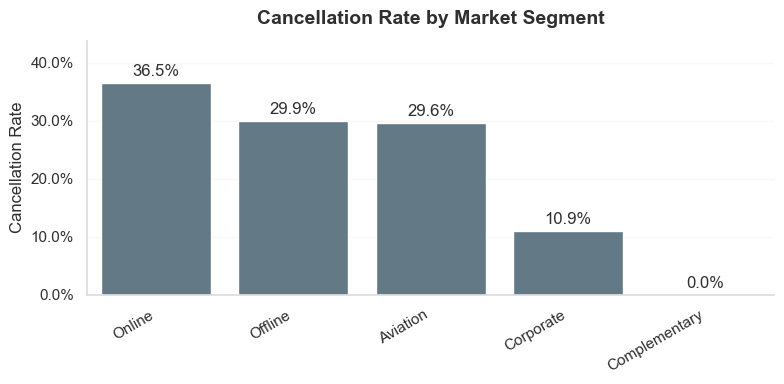

In [47]:
# Visualize cancellation rate by market segment

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=market_cancellation,
    x="market_segment_type",
    y="cancellation_rate",
    color=project_palette["slate_blue"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.1%}" for v in container],
        padding=3,
        color=chart_colors["text"]
    )

plt.title("Cancellation Rate by Market Segment", fontsize=14, weight="bold", pad=12, color=chart_colors["text"])
plt.xlabel("")
plt.ylabel("Cancellation Rate", color=chart_colors["text"])
plt.ylim(0, market_cancellation["cancellation_rate"].max() * 1.2)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

### Market Segment Insights

Cancellation behavior varies clearly by market segment.

The `Online` segment shows the highest cancellation rate at approximately 36.5%, followed by `Offline` and `Aviation`, both around 30%. In contrast, `Corporate` bookings show a much lower cancellation rate, close to 10.9%.

The `Complementary` segment has no cancellations in this dataset, although this group is relatively small.

This suggests that the booking channel may be an important predictor for the machine learning model, especially when distinguishing between online and corporate reservations.

## 8. Cancellation Pattern by Lead Time

Lead time represents the number of days between the booking date and the arrival date.

This variable is highly relevant because reservations made far in advance may have a higher probability of cancellation.

In [48]:
# Create lead time groups

df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, df_clean["lead_time"].max()],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181-365 days", "365+ days"]
)

lead_time_cancellation = (
    df_clean
    .groupby("lead_time_group", observed=True)
    .agg(
        total_bookings=("booking_status", "count"),
        canceled_bookings=("booking_status", lambda x: (x == "Canceled").sum())
    )
    .reset_index()
)

lead_time_cancellation["cancellation_rate"] = lead_time_cancellation["canceled_bookings"] / lead_time_cancellation["total_bookings"]

lead_time_cancellation

,lead_time_group,total_bookings,canceled_bookings,cancellation_rate
0,0-7 days,5801,514,0.088605
1,8-30 days,6610,1249,0.188956
2,31-90 days,10815,2733,0.252705
3,91-180 days,7772,3490,0.449048
4,181-365 days,5034,3668,0.728645
5,365+ days,243,231,0.950617


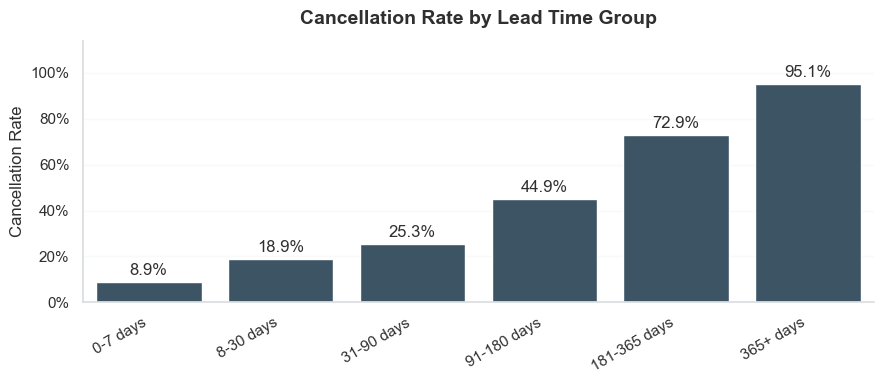

In [49]:
# Visualize cancellation rate by lead time group

plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=lead_time_cancellation,
    x="lead_time_group",
    y="cancellation_rate",
    color=chart_colors["canceled"]
)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{v.get_height():.1%}" for v in container], padding=3, color=chart_colors["text"])

plt.title("Cancellation Rate by Lead Time Group", fontsize=14, weight="bold", pad=12, color=chart_colors["text"])
plt.xlabel("")
plt.ylabel("Cancellation Rate", color=chart_colors["text"])
plt.ylim(0, lead_time_cancellation["cancellation_rate"].max() * 1.2)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

### Lead Time Insights

Cancellation rates increase strongly as lead time becomes longer.

Bookings made within one week of arrival have a very low cancellation rate, below 10%. In contrast, bookings made more than 180 days in advance show very high cancellation rates, above 70%.

The `365+ days` group has the highest cancellation rate, although it represents a small number of bookings.

This suggests that `lead_time` is likely to be one of the most important predictors in the machine learning model.

In [50]:
# Remove temporary EDA feature before modeling dataset preparation

df_clean = df_clean.drop(columns=["lead_time_group"])

## 9. Cancellation Pattern by Special Requests

The number of special requests may reflect how engaged a guest is with the booking.

In this section, we analyze whether bookings with more special requests are less likely to be cancelled.

In [51]:
# Cancellation rate by number of special requests

special_requests_cancellation = (
    df_clean
    .groupby("no_of_special_requests")
    .agg(
        total_bookings=("booking_status", "count"),
        canceled_bookings=("booking_status", lambda x: (x == "Canceled").sum())
    )
    .reset_index()
)

special_requests_cancellation["cancellation_rate"] = (
    special_requests_cancellation["canceled_bookings"] / special_requests_cancellation["total_bookings"]
)

special_requests_cancellation

,no_of_special_requests,total_bookings,canceled_bookings,cancellation_rate
0,0,19777,8545,0.432068
1,1,11373,2703,0.237668
2,2,4364,637,0.145967
3,3,675,0,0.000000
4,4,78,0,0.000000
5,5,8,0,0.000000


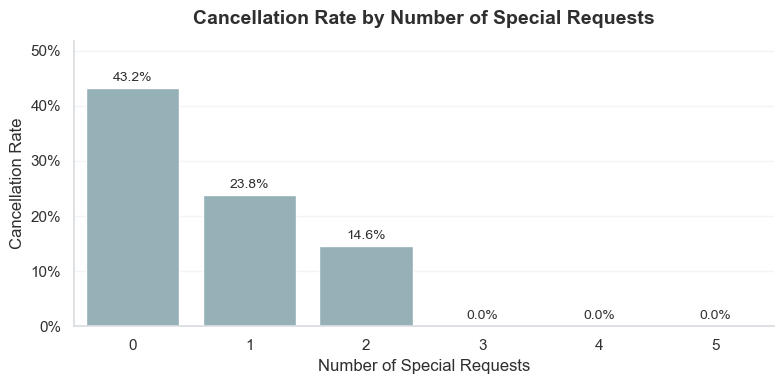

In [55]:
# Visualize cancellation rate by number of special requests

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=special_requests_cancellation,
    x="no_of_special_requests",
    y="cancellation_rate",
    color=project_palette["soft_teal"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.1%}" for v in container],
        padding=3,
        color=chart_colors["text"],
        fontsize=10
    )

plt.title(
    "Cancellation Rate by Number of Special Requests",
    fontsize=14,
    weight="bold",
    pad=12,
    color=chart_colors["text"]
)

plt.xlabel("Number of Special Requests", color=chart_colors["text"])
plt.ylabel("Cancellation Rate", color=chart_colors["text"])
plt.ylim(0, special_requests_cancellation["cancellation_rate"].max() * 1.2)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(color=chart_colors["text"])
plt.yticks(color=chart_colors["text"])
plt.grid(axis="y", color=chart_colors["grid"], alpha=0.45)

sns.despine()
plt.tight_layout()
plt.show()

### Special Requests Insights

Cancellation rates decrease clearly as the number of special requests increases.

Bookings with no special requests have the highest cancellation rate, above 43%. In contrast, bookings with one or two special requests show substantially lower cancellation rates.

Bookings with three or more special requests show no cancellations in this dataset, although these groups contain fewer observations.

This suggests that `no_of_special_requests` may be an important predictor, potentially capturing guest engagement or booking commitment.

## 10. Cancellation Pattern by Average Room Price

Average room price may influence cancellation behavior, especially if more expensive bookings are associated with different customer expectations, booking channels, or flexibility.

To make the relationship easier to interpret, room prices are grouped into price ranges.

In [56]:
# Create room price groups

df_clean["price_group"] = pd.cut(
    df_clean["avg_price_per_room"],
    bins=[-1, 0, 75, 100, 125, 150, df_clean["avg_price_per_room"].max()],
    labels=["0", "1-75", "76-100", "101-125", "126-150", "150+"]
)

price_cancellation = (
    df_clean
    .groupby("price_group", observed=True)
    .agg(
        total_bookings=("booking_status", "count"),
        canceled_bookings=("booking_status", lambda x: (x == "Canceled").sum())
    )
    .reset_index()
)

price_cancellation["cancellation_rate"] = price_cancellation["canceled_bookings"] / price_cancellation["total_bookings"]

price_cancellation

,price_group,total_bookings,canceled_bookings,cancellation_rate
0,0,545,6,0.011009
1,1-75,6238,1306,0.209362
2,76-100,12102,3540,0.292514
3,101-125,9243,3970,0.429514
4,126-150,4927,1905,0.386645
5,150+,3220,1158,0.359627


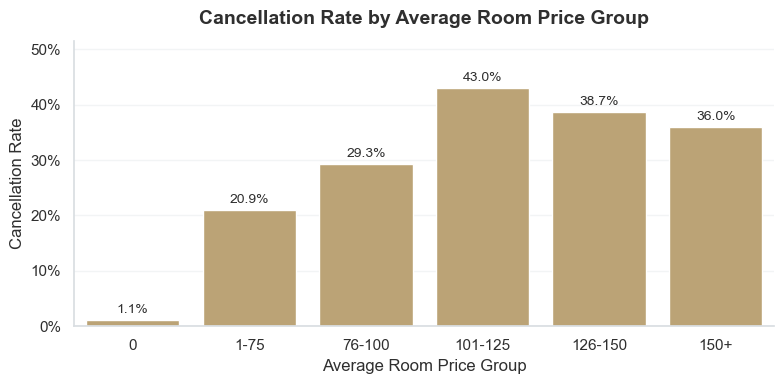

In [58]:
# Visualize cancellation rate by room price group

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=price_cancellation,
    x="price_group",
    y="cancellation_rate",
    color=project_palette["muted_gold"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.1%}" for v in container],
        padding=3,
        color=chart_colors["text"],
        fontsize=10
    )

plt.title(
    "Cancellation Rate by Average Room Price Group",
    fontsize=14,
    weight="bold",
    pad=12,
    color=chart_colors["text"]
)

plt.xlabel("Average Room Price Group", color=chart_colors["text"])
plt.ylabel("Cancellation Rate", color=chart_colors["text"])
plt.ylim(0, price_cancellation["cancellation_rate"].max() * 1.2)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(color=chart_colors["text"])
plt.yticks(color=chart_colors["text"])
plt.grid(axis="y", color=chart_colors["grid"], alpha=0.45)

sns.despine()
plt.tight_layout()
plt.show()

In [59]:
# Remove temporary EDA feature before modeling dataset preparation

df_clean = df_clean.drop(columns=["price_group"])

### Average Room Price Insights

Cancellation rates vary across room price groups, but the relationship is not fully linear.

Zero-price bookings show a very low cancellation rate, which is consistent with the earlier finding that most of these bookings belong to the `Complementary` segment.

The highest cancellation rate appears in the `101-125` price range, where more than 40% of bookings were cancelled. Higher price groups still show relatively high cancellation rates, but not higher than this middle-price segment.

This suggests that `avg_price_per_room` may contain useful predictive information, although its relationship with cancellation behavior is more complex than a simple “higher price means higher cancellation risk” pattern.

## 11. Cancellation Pattern by Room Type

Room type may influence cancellation behavior if certain room categories are associated with different customer profiles, prices, or booking intentions.

In this section, we compare cancellation rates across reserved room types.

In [60]:
# Cancellation rate by reserved room type

room_type_cancellation = (
    df_clean
    .groupby("room_type_reserved")
    .agg(
        total_bookings=("booking_status", "count"),
        canceled_bookings=("booking_status", lambda x: (x == "Canceled").sum())
    )
    .reset_index()
)

room_type_cancellation["cancellation_rate"] = (
    room_type_cancellation["canceled_bookings"] / room_type_cancellation["total_bookings"]
)

room_type_cancellation = room_type_cancellation.sort_values("cancellation_rate", ascending=False)

room_type_cancellation

,room_type_reserved,total_bookings,canceled_bookings,cancellation_rate
5,Room_Type 6,966,406,0.420290
3,Room_Type 4,6057,2069,0.341588
1,Room_Type 2,692,228,0.329480
0,Room_Type 1,28130,9072,0.322503
2,Room_Type 3,7,2,0.285714
4,Room_Type 5,265,72,0.271698
6,Room_Type 7,158,36,0.227848


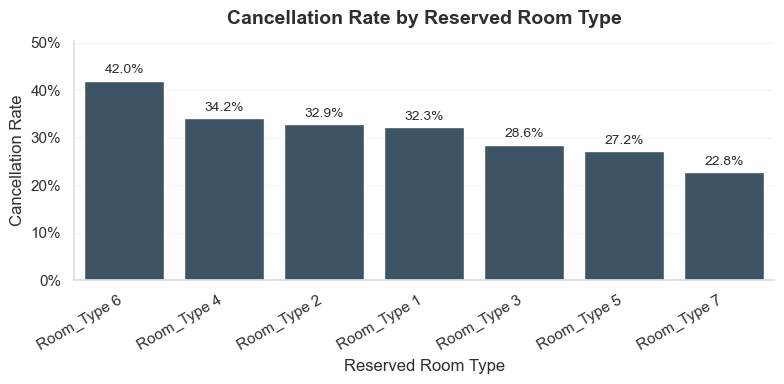

In [62]:
# Visualize cancellation rate by reserved room type

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=room_type_cancellation,
    x="room_type_reserved",
    y="cancellation_rate",
    color=project_palette["hotel_blue"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.1%}" for v in container],
        padding=3,
        color=chart_colors["text"],
        fontsize=10
    )

plt.title(
    "Cancellation Rate by Reserved Room Type",
    fontsize=14,
    weight="bold",
    pad=12,
    color=chart_colors["text"]
)

plt.xlabel("Reserved Room Type", color=chart_colors["text"])
plt.ylabel("Cancellation Rate", color=chart_colors["text"])
plt.ylim(0, room_type_cancellation["cancellation_rate"].max() * 1.2)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=30, ha="right", color=chart_colors["text"])
plt.yticks(color=chart_colors["text"])
plt.grid(axis="y", color=chart_colors["grid"], alpha=0.45)

sns.despine()
plt.tight_layout()
plt.show()

### Room Type Insights

Cancellation rates vary across reserved room types, although the differences are less pronounced than in variables such as `lead_time` or `no_of_special_requests`.

`Room_Type 6` shows the highest cancellation rate, above 40%, but it represents a relatively small portion of the dataset. The most common category, `Room_Type 1`, has a cancellation rate close to the overall dataset average.

This suggests that room type may provide some predictive value, but it is unlikely to be one of the strongest drivers on its own.

## 12. Cancellation Pattern by Meal Plan

Meal plan selection may reflect booking preferences, price sensitivity, or commitment level.

In this section, we compare cancellation rates across different meal plan categories.

In [63]:
# Cancellation rate by meal plan

meal_plan_cancellation = (
    df_clean
    .groupby("type_of_meal_plan")
    .agg(
        total_bookings=("booking_status", "count"),
        canceled_bookings=("booking_status", lambda x: (x == "Canceled").sum())
    )
    .reset_index()
)

meal_plan_cancellation["cancellation_rate"] = (
    meal_plan_cancellation["canceled_bookings"] / meal_plan_cancellation["total_bookings"]
)

meal_plan_cancellation = meal_plan_cancellation.sort_values("cancellation_rate", ascending=False)

meal_plan_cancellation

,type_of_meal_plan,total_bookings,canceled_bookings,cancellation_rate
1,Meal Plan 2,3305,1506,0.455673
3,Not Selected,5130,1699,0.331189
0,Meal Plan 1,27835,8679,0.311802
2,Meal Plan 3,5,1,0.200000


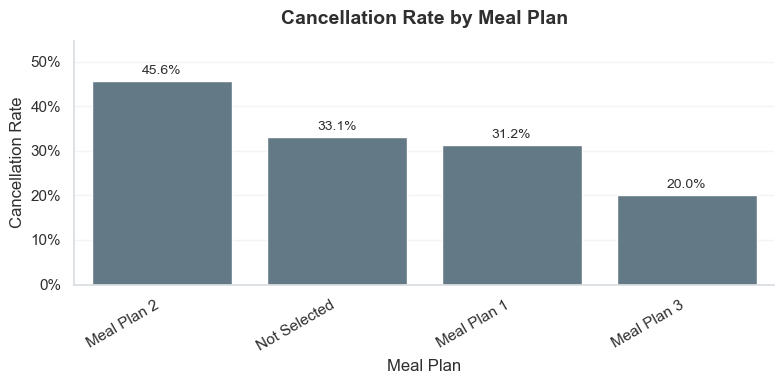

In [65]:
# Visualize cancellation rate by meal plan

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=meal_plan_cancellation,
    x="type_of_meal_plan",
    y="cancellation_rate",
    color=project_palette["slate_blue"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.1%}" for v in container],
        padding=3,
        color=chart_colors["text"],
        fontsize=10
    )

plt.title(
    "Cancellation Rate by Meal Plan",
    fontsize=14,
    weight="bold",
    pad=12,
    color=chart_colors["text"]
)

plt.xlabel("Meal Plan", color=chart_colors["text"])
plt.ylabel("Cancellation Rate", color=chart_colors["text"])
plt.ylim(0, meal_plan_cancellation["cancellation_rate"].max() * 1.2)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=30, ha="right", color=chart_colors["text"])
plt.yticks(color=chart_colors["text"])
plt.grid(axis="y", color=chart_colors["grid"], alpha=0.45)

sns.despine()
plt.tight_layout()
plt.show()

### Meal Plan Insights

Cancellation rates differ across meal plan categories.

`Meal Plan 2` shows the highest cancellation rate, above 45%, suggesting that this category may be associated with higher cancellation risk.

`Meal Plan 1` and `Not Selected` show more moderate cancellation rates, while `Meal Plan 3` should be interpreted with caution because it contains only a very small number of bookings.

Overall, meal plan selection may provide useful information for the machine learning model.

## 13. EDA Summary

The exploratory analysis revealed several useful patterns related to hotel booking cancellations:

- `lead_time` shows a strong relationship with cancellation behavior. Bookings made further in advance are much more likely to be cancelled.
- `no_of_special_requests` appears to be negatively associated with cancellations. Guests with more special requests tend to cancel less often.
- `market_segment_type` is relevant, with online bookings showing the highest cancellation rate and corporate bookings showing a much lower rate.
- `avg_price_per_room` contains useful information, although its relationship with cancellations is not strictly linear.
- `type_of_meal_plan` and `room_type_reserved` also show some variation in cancellation rates, but their individual impact appears weaker than lead time or special requests.

These findings suggest that the dataset contains meaningful predictive signals for a supervised classification model.

In [66]:
# Final dataset check before modeling

df_clean.shape, df_clean.columns.tolist()

((36275, 19),
 ['booking_id',
  'no_of_adults',
  'no_of_children',
  'no_of_weekend_nights',
  'no_of_week_nights',
  'type_of_meal_plan',
  'required_car_parking_space',
  'room_type_reserved',
  'lead_time',
  'arrival_year',
  'arrival_month',
  'arrival_date',
  'market_segment_type',
  'repeated_guest',
  'no_of_previous_cancellations',
  'no_of_previous_bookings_not_canceled',
  'avg_price_per_room',
  'no_of_special_requests',
  'booking_status'])

In [67]:
# Save final cleaned dataset

df_clean.to_csv("../data/processed/hotel_reservations_clean.csv", index=False)

print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.
